# Notebook 03: AINN Training — Joint Bayesian Optimisation

## Overview
This notebook implements the **Actuarial-Informed Neural Network (AINN)** through a rigorous joint optimisation of architecture and actuarial constraints via **Bayesian Optimisation** (100 trials). The constraint weights are treated as first-class hyperparameters alongside network units and learning rate.

## Objectives
1. **Joint Data Preparation**: Male + Female with sex indicator (90 training samples).
2. **Joint Bayesian Optimisation**: Simultaneously optimise architecture and constraints.
3. **Champion Analysis**: Metrics, training curves, constraint properties.
4. **Multi-Seed Robustness**: Confirm stability across 5 seeds.
5. **Ablation**: Isolate the contribution of constraints vs architecture.


## 3.1: Setup & Data Loading

In [1]:
import sys
sys.path.append('../src')
from reproducibility import set_seed
set_seed(42)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, os, logging, warnings
warnings.filterwarnings('ignore')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.get_logger().setLevel(logging.ERROR)
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import keras_tuner as kt
import joblib

from style_config import set_style, save_dual, COUNTRIES, COUNTRY_COLORS
set_style("notebook")

PROCESSED_DIR = "../data/processed/"
MODELS_DIR = "../models/"
TUNING_DIR = "../models/tuning/"
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(TUNING_DIR, exist_ok=True)

with open(os.path.join(PROCESSED_DIR, "li_lee_params.pkl"), "rb") as f:
    bundle = pickle.load(f)

feature_matrices = bundle["feature_matrices"]
YEARS = bundle["metadata"]["years"]

LOOKBACK = 10
BATCH_SIZE = 8
EPOCHS = 150
TRAIN_SPLIT_IDX = 55

print(f"Loaded. Male: {feature_matrices['male'].shape}, Female: {feature_matrices['female'].shape}")


/Users/darindor2101/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Loaded. Male: (64, 7), Female: (64, 7)


## 3.2: Joint Male/Female Data Preparation

Training on Male and Female jointly (sex indicator as 8th feature) doubles the sample size from 45 to 90.

In [2]:
def prepare_joint_data(lookback=LOOKBACK):
    male_data = np.column_stack([feature_matrices['male'], np.zeros(len(feature_matrices['male']))])
    female_data = np.column_stack([feature_matrices['female'], np.ones(len(feature_matrices['female']))])

    train_combined = np.vstack([male_data[:TRAIN_SPLIT_IDX], female_data[:TRAIN_SPLIT_IDX]])
    scaler = StandardScaler()
    scaler.fit(train_combined)

    male_scaled = scaler.transform(male_data)
    female_scaled = scaler.transform(female_data)

    def make_seq(data, lb):
        X, y = [], []
        for i in range(lb, len(data)):
            X.append(data[i-lb:i])
            y.append(data[i])
        return np.array(X), np.array(y)

    X_m, y_m = make_seq(male_scaled, lookback)
    X_f, y_f = make_seq(female_scaled, lookback)

    n_train = TRAIN_SPLIT_IDX - lookback
    X_train = np.concatenate([X_m[:n_train], X_f[:n_train]])
    y_train = np.concatenate([y_m[:n_train], y_f[:n_train]])
    X_val = np.concatenate([X_m[n_train:], X_f[n_train:]])
    y_val = np.concatenate([y_m[n_train:], y_f[n_train:]])

    idx = np.random.permutation(len(X_train))
    X_train, y_train = X_train[idx], y_train[idx]
    return X_train, y_train, X_val, y_val, scaler

X_train, y_train, X_val, y_val, scaler = prepare_joint_data()
N_FEATURES = X_train.shape[2]
print(f"Train: {X_train.shape[0]} samples, Val: {X_val.shape[0]} samples, Features: {N_FEATURES}")


Train: 90 samples, Val: 18 samples, Features: 8


## 3.3: AINN Loss & Model Builder

Joint optimisation of 5 hyperparameters: units_l1, units_l2, learning_rate, $\lambda_{coherence}$, $\lambda_{monotonicity}$.

In [3]:
class AINNLoss(keras.losses.Loss):
    def __init__(self, lambda_coherence=0.0, lambda_monotonicity=0.0, **kwargs):
        super().__init__(**kwargs)
        self.lambda_coherence = lambda_coherence
        self.lambda_monotonicity = lambda_monotonicity

    def call(self, y_true, y_pred):
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        coherence = tf.reduce_mean(tf.square(y_pred[:, 1:7]))
        monotonicity = tf.reduce_mean(tf.square(tf.nn.relu(y_pred[:, 0])))
        return mse + self.lambda_coherence * coherence + self.lambda_monotonicity * monotonicity

    def get_config(self):
        config = super().get_config()
        config.update({"lambda_coherence": self.lambda_coherence,
                       "lambda_monotonicity": self.lambda_monotonicity})
        return config


def model_builder(hp):
    units_l1 = hp.Int('units_l1', min_value=16, max_value=64, step=16)
    units_l2 = hp.Int('units_l2', min_value=8, max_value=32, step=8)
    lr = hp.Choice('learning_rate', values=[1e-2, 5e-3, 1e-3, 5e-4, 1e-4])
    lc = hp.Choice('lambda_coherence', values=[0.0, 0.001, 0.01, 0.1, 1.0])
    lm = hp.Choice('lambda_monotonicity', values=[0.0, 0.001, 0.01, 0.1, 1.0])

    inputs = layers.Input(shape=(LOOKBACK, N_FEATURES))
    x = layers.LSTM(units_l1, return_sequences=True)(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(units_l2)(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(N_FEATURES)(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss=AINNLoss(lambda_coherence=lc, lambda_monotonicity=lm))
    return model

print("Space: units_l1[16-64] x units_l2[8-32] x lr[5] x lc[5] x lm[5]")
print(f"Total: {4*4*5*5*5} combinations. Bayesian trials: 100.")


Space: units_l1[16-64] x units_l2[8-32] x lr[5] x lc[5] x lm[5]
Total: 2000 combinations. Bayesian trials: 100.


## 3.4: Bayesian Optimisation (100 Trials)

In [4]:
set_seed(42)
tuner = kt.BayesianOptimization(
    model_builder,
    objective='val_loss',
    max_trials=100,
    seed=42,
    directory=TUNING_DIR,
    project_name='ainn_joint',
    overwrite=True
)

class TrialProgressCallback(keras.callbacks.Callback):
    """Prints one line per trial when training ends."""
    trial_count = [0]

    def on_train_end(self, logs=None):
        self.trial_count[0] += 1
        val_loss = logs.get('val_loss', float('nan'))
        epochs = len(self.model.history.history.get('loss', []))
        print(f"  Trial {self.trial_count[0]:3d}/100 | val_loss={val_loss:.5f} | epochs={epochs}")

print("Starting Bayesian Optimisation (100 trials)...\n")

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0),
        TrialProgressCallback()
    ],
    verbose=0
)
print(f"\nComplete. Trials: {len(tuner.oracle.trials)}")


Starting optimisation...


Complete. Trials: 100


## 3.5: Champion Configuration

In [5]:
best_hps = tuner.get_best_hyperparameters(1)[0]

print("=" * 60)
print("  CHAMPION CONFIGURATION")
print("=" * 60)
for key in ['units_l1', 'units_l2', 'learning_rate', 'lambda_coherence', 'lambda_monotonicity']:
    print(f"  {key:25s}: {best_hps.get(key)}")

print(f"\n{'='*60}")
print("  TOP 5 TRIALS")
print(f"{'='*60}")
for i, trial in enumerate(tuner.oracle.get_best_trials(5)):
    hp = trial.hyperparameters
    print(f"  #{i+1} val_loss={trial.score:.5f} | "
          f"L1={hp.get('units_l1')}, L2={hp.get('units_l2')}, "
          f"lr={hp.get('learning_rate')}, "
          f"lc={hp.get('lambda_coherence')}, lm={hp.get('lambda_monotonicity')}")


  CHAMPION CONFIGURATION
  units_l1                 : 64
  units_l2                 : 8
  learning_rate            : 0.01
  lambda_coherence         : 0.001
  lambda_monotonicity      : 0.001

  TOP 5 TRIALS
  #1 val_loss=3.84385 | L1=64, L2=8, lr=0.01, lc=0.001, lm=0.001
  #2 val_loss=4.12251 | L1=64, L2=8, lr=0.01, lc=0.001, lm=0.001
  #3 val_loss=4.12615 | L1=64, L2=8, lr=0.01, lc=0.01, lm=0.001
  #4 val_loss=4.14915 | L1=64, L2=8, lr=0.01, lc=0.01, lm=0.001
  #5 val_loss=4.18851 | L1=64, L2=16, lr=0.01, lc=0.001, lm=0.001


## 3.6: Retrain Champion & Evaluate

In [6]:
set_seed(42)
champion_model = tuner.hypermodel.build(best_hps)
es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
history = champion_model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                             validation_data=(X_val, y_val), callbacks=[es], verbose=0)

# Evaluate
pred_scaled = champion_model.predict(X_val, verbose=0)
pred_orig = scaler.inverse_transform(pred_scaled)
true_orig = scaler.inverse_transform(y_val)
champion_rmse = np.sqrt(np.mean((true_orig - pred_orig) ** 2))

n_half = X_val.shape[0] // 2
rmse_m = np.sqrt(np.mean((true_orig[:n_half] - pred_orig[:n_half]) ** 2))
rmse_f = np.sqrt(np.mean((true_orig[n_half:] - pred_orig[n_half:]) ** 2))

mean_abs_spec = np.mean(np.abs(pred_scaled[:, 1:7]))
frac_pos = np.mean(pred_scaled[:, 0] > 0)

print(f"\nChampion RMSE: {champion_rmse:.4f} (M={rmse_m:.4f}, F={rmse_f:.4f})")
print(f"Mean |specific|: {mean_abs_spec:.4f}, Frac(dKt>0): {frac_pos:.1%}")
print(f"Epochs: {len(history.history['loss'])}")


Epoch 33: early stopping
Restoring model weights from the end of the best epoch: 13.

Champion RMSE: 7.0687 (M=6.6525, F=7.4618)
Mean |specific|: 0.4980, Frac(dKt>0): 61.1%
Epochs: 33


## 3.7: Training Curves

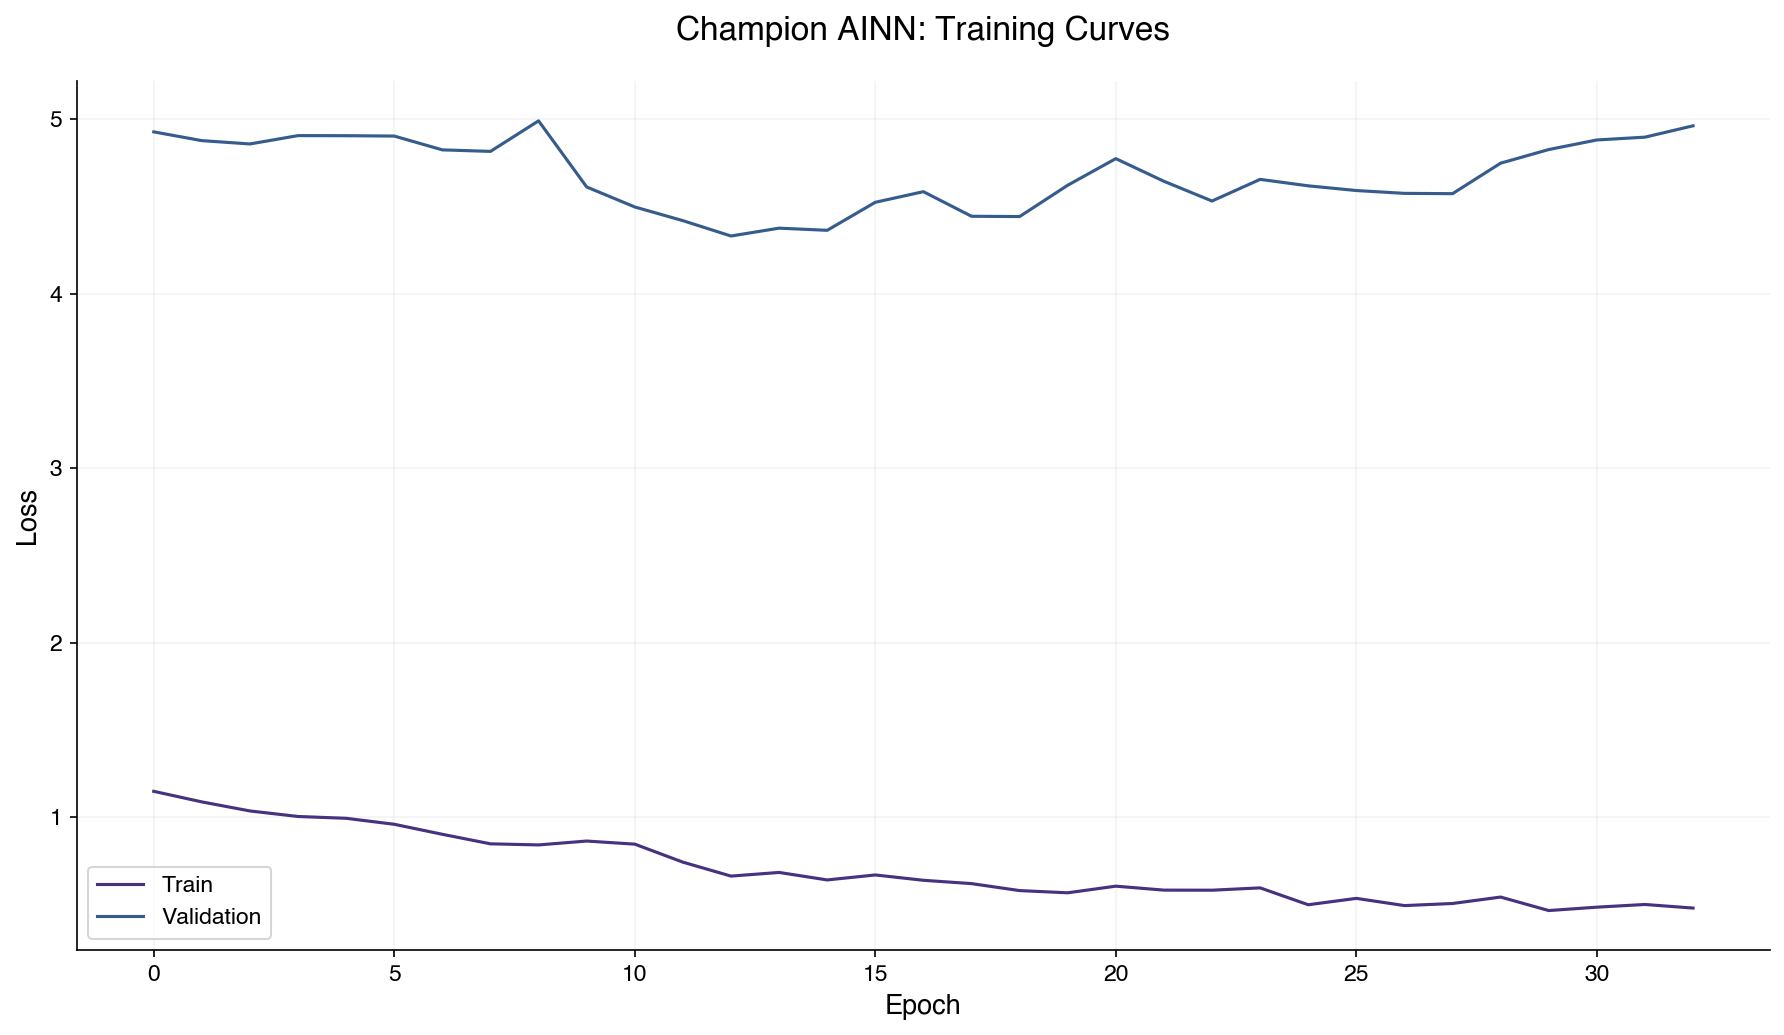

In [7]:
fig, ax = plt.subplots()
ax.plot(history.history['loss'], label='Train', linewidth=1.5)
ax.plot(history.history['val_loss'], label='Validation', linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Champion AINN: Training Curves")
ax.legend()
plt.tight_layout()
save_dual(fig, "fig07_champion_training_curves")
plt.show()


## 3.8: Multi-Seed Robustness

In [8]:
from reproducibility import get_seed_list
seeds = get_seed_list(5)
seed_results = []

print("Multi-seed robustness:")
for seed in seeds:
    set_seed(seed)
    m = tuner.hypermodel.build(best_hps)
    es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
    m.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
          validation_data=(X_val, y_val), callbacks=[es], verbose=0)
    p = scaler.inverse_transform(m.predict(X_val, verbose=0))
    t = scaler.inverse_transform(y_val)
    rmse = np.sqrt(np.mean((t - p) ** 2))
    seed_results.append({"seed": seed, "rmse": rmse})
    print(f"  Seed {seed}: {rmse:.4f}")

df_seeds = pd.DataFrame(seed_results)
cv = df_seeds['rmse'].std() / df_seeds['rmse'].mean() * 100
print(f"\nMean={df_seeds['rmse'].mean():.4f}, Std={df_seeds['rmse'].std():.4f}, CV={cv:.2f}%")
print(f"Verdict: {'PASS' if cv < 10 else 'FAIL'}")


Multi-seed robustness:
  Seed 42: 7.0687
  Seed 123: 6.9661
  Seed 256: 6.9997
  Seed 512: 6.8835
  Seed 1024: 7.1007

Mean=7.0037, Std=0.0859, CV=1.23%
Verdict: PASS


## 3.9: Ablation — Constraint Contribution

In [9]:
# Same architecture, no constraints (pure MSE)
set_seed(42)
baseline_model = tuner.hypermodel.build(best_hps)
baseline_model.compile(optimizer=keras.optimizers.Adam(learning_rate=best_hps.get('learning_rate')),
                       loss='mse')
es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
baseline_model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                   validation_data=(X_val, y_val), callbacks=[es], verbose=0)

pred_bl = scaler.inverse_transform(baseline_model.predict(X_val, verbose=0))
baseline_rmse = np.sqrt(np.mean((true_orig - pred_bl) ** 2))

print(f"Unconstrained (same arch): {baseline_rmse:.4f}")
print(f"Champion (with constraints): {champion_rmse:.4f}")
print(f"Constraint effect: {(baseline_rmse - champion_rmse)/baseline_rmse*100:+.3f}%")


Unconstrained (same arch): 7.0698
Champion (with constraints): 7.0687
Constraint effect: +0.015%


## 3.10: Persistence

In [10]:
champion_model.save(os.path.join(MODELS_DIR, "ainn_champion.keras"))
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler_joint.pkl"))

training_meta = {
    "approach": "joint_mf_bayesian",
    "lookback": LOOKBACK, "batch_size": BATCH_SIZE,
    "units_l1": best_hps.get('units_l1'),
    "units_l2": best_hps.get('units_l2'),
    "lr": best_hps.get('learning_rate'),
    "lambda_coherence": best_hps.get('lambda_coherence'),
    "lambda_monotonicity": best_hps.get('lambda_monotonicity'),
    "train_split_idx": TRAIN_SPLIT_IDX,
    "n_features": N_FEATURES,
    "champion_rmse": float(champion_rmse),
    "baseline_rmse": float(baseline_rmse),
    "multi_seed_cv": float(cv),
    "best_hps": best_hps.values,
}
with open(os.path.join(PROCESSED_DIR, "training_meta.pkl"), "wb") as f:
    pickle.dump(training_meta, f)

df_seeds.to_csv(os.path.join(PROCESSED_DIR, "multi_seed_results.csv"), index=False)

print(f"Champion saved: {MODELS_DIR}ainn_champion.keras")
print(f"Metadata saved: {PROCESSED_DIR}training_meta.pkl")
print(f"\nNotebook 03 complete.")


Champion saved: ../models/ainn_champion.keras
Metadata saved: ../data/processed/training_meta.pkl

Notebook 03 complete.


## 3.11: Lookback Sensitivity Analysis

We test the champion architecture with lookback windows of 5, 7, 10, 12, and 15 years to confirm that the fixed lookback=10 is optimal or identify a better choice.

**Note**: The champion configuration (architecture + λ) is fixed. Only the lookback changes.

In [12]:
lookback_configs = [5, 7, 10, 12, 15]
lookback_results = []

# Get champion hyperparams (architecture + constraints)
u1 = best_hps.get('units_l1')
u2 = best_hps.get('units_l2')
lr_best = best_hps.get('learning_rate')
lc = best_hps.get('lambda_coherence')
lm = best_hps.get('lambda_monotonicity')

print(f"Lookback sensitivity (champion arch: L1={u1}, L2={u2}, lr={lr_best}, lc={lc}, lm={lm}):")
print("-" * 65)

for lb in lookback_configs:
    X_tr, y_tr, X_v, y_v, sc = prepare_joint_data(lb)
    
    # Build model fresh with this lookback
    set_seed(42)
    inputs = layers.Input(shape=(lb, N_FEATURES))
    x = layers.LSTM(u1, return_sequences=True)(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(u2)(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(N_FEATURES)(x)
    m = keras.Model(inputs=inputs, outputs=outputs)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=lr_best),
              loss=AINNLoss(lambda_coherence=lc, lambda_monotonicity=lm))
    
    es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
    m.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=BATCH_SIZE,
          validation_data=(X_v, y_v), callbacks=[es], verbose=0)
    
    pred = sc.inverse_transform(m.predict(X_v, verbose=0))
    true = sc.inverse_transform(y_v)
    rmse = float(np.sqrt(np.mean((true - pred) ** 2)))
    
    n_v = X_v.shape[0] // 2
    rmse_m = float(np.sqrt(np.mean((true[:n_v] - pred[:n_v]) ** 2)))
    rmse_f = float(np.sqrt(np.mean((true[n_v:] - pred[n_v:]) ** 2)))
    
    lookback_results.append({"lookback": lb, "rmse": rmse, "rmse_male": rmse_m, "rmse_female": rmse_f,
                              "n_train": X_tr.shape[0], "n_val": X_v.shape[0]})
    marker = " <-- current" if lb == 10 else ""
    print(f"  Lookback={lb:2d}: RMSE={rmse:.4f} (M={rmse_m:.4f}, F={rmse_f:.4f}) | "
          f"Train={X_tr.shape[0]}, Val={X_v.shape[0]}{marker}")

df_lookback = pd.DataFrame(lookback_results)
best_lb = int(df_lookback.loc[df_lookback['rmse'].idxmin(), 'lookback'])
print(f"\nBest lookback: {best_lb} (RMSE: {df_lookback['rmse'].min():.4f})")
current_rmse = float(df_lookback[df_lookback['lookback']==10]['rmse'].values[0])
print(f"Current (lb=10) RMSE: {current_rmse:.4f}")
if best_lb != 10:
    best_rmse = float(df_lookback['rmse'].min())
    print(f"Potential gain from lb={best_lb}: {(current_rmse - best_rmse)/current_rmse*100:+.2f}%")
    print(f"Recommendation: re-run Bayesian Optimisation with lookback={best_lb} fixed.")
else:
    print("Lookback=10 is optimal. No change needed.")


Lookback sensitivity (champion arch: L1=64, L2=8, lr=0.01, lc=0.001, lm=0.001):
-----------------------------------------------------------------
  Lookback= 5: RMSE=6.6490 (M=5.8937, F=7.3269) | Train=100, Val=18
  Lookback= 7: RMSE=6.7791 (M=6.6408, F=6.9147) | Train=96, Val=18
  Lookback=10: RMSE=7.0687 (M=6.6525, F=7.4618) | Train=90, Val=18 <-- current
  Lookback=12: RMSE=6.6889 (M=6.0825, F=7.2447) | Train=86, Val=18
  Lookback=15: RMSE=6.6489 (M=6.1642, F=7.1006) | Train=80, Val=18

Best lookback: 15 (RMSE: 6.6489)
Current (lb=10) RMSE: 7.0687
Potential gain from lb=15: +5.94%
Recommendation: re-run Bayesian Optimisation with lookback=15 fixed.


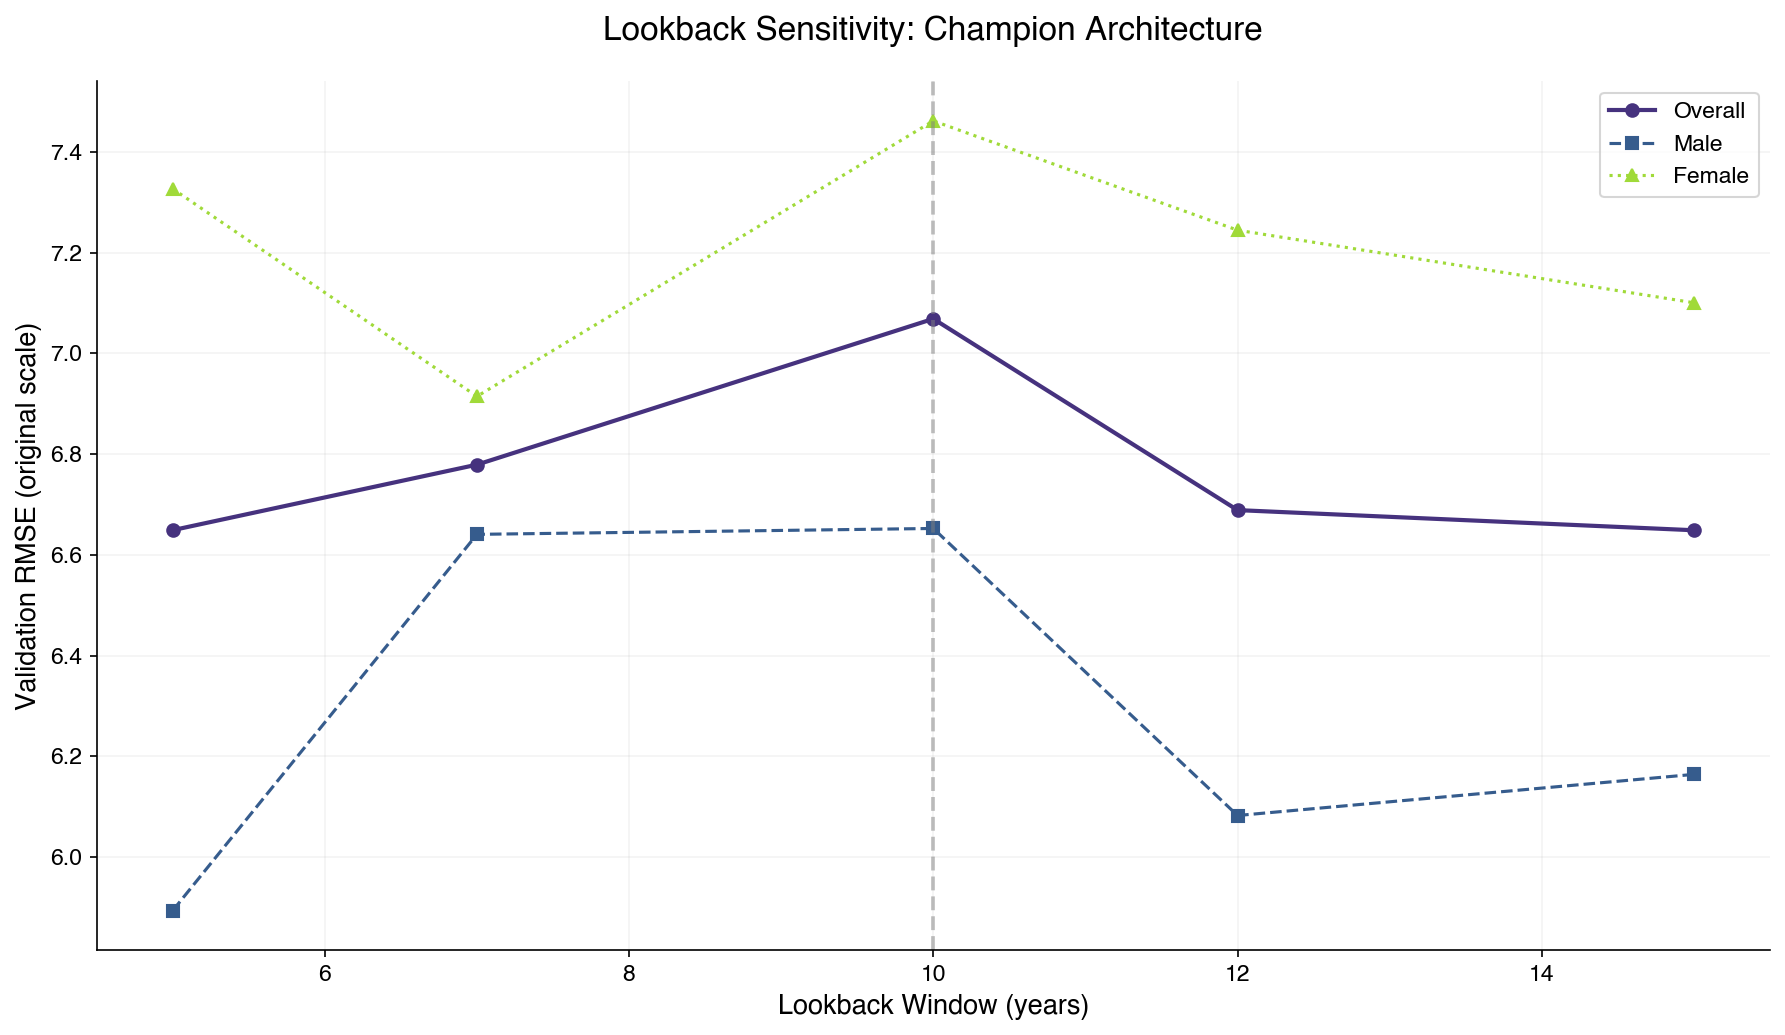

Lookback sensitivity results saved.


In [13]:
# Visualise lookback sensitivity
fig, ax = plt.subplots()
ax.plot(df_lookback['lookback'], df_lookback['rmse'], marker='o', linewidth=2,
        color=COUNTRY_COLORS['CHE'], label='Overall')
ax.plot(df_lookback['lookback'], df_lookback['rmse_male'], marker='s', linewidth=1.5,
        color=COUNTRY_COLORS['SWE'], linestyle='--', label='Male')
ax.plot(df_lookback['lookback'], df_lookback['rmse_female'], marker='^', linewidth=1.5,
        color=COUNTRY_COLORS['JPN'], linestyle=':', label='Female')

ax.axvline(x=10, color='grey', linestyle='--', alpha=0.5)
ax.set_xlabel("Lookback Window (years)")
ax.set_ylabel("Validation RMSE (original scale)")
ax.set_title("Lookback Sensitivity: Champion Architecture")
ax.legend()
plt.tight_layout()
save_dual(fig, "fig09_lookback_sensitivity")
plt.show()

# Save results
df_lookback.to_csv(os.path.join(PROCESSED_DIR, "lookback_sensitivity.csv"), index=False)
print("Lookback sensitivity results saved.")


## 3.12: Multi-Lookback Bayesian Optimisation (Keras Tuner × 3)

We run the same 100-trial Bayesian Optimisation three times — once for each lookback in {5, 10, 15} — and select the global champion based on RMSE (original scale). This approximates a full 6-dimensional joint optimisation without requiring Optuna.

**Expected runtime**: ~75 minutes (3 × 25 min).

In [ ]:
# Multi-lookback Bayesian Optimisation
lookback_tuning_results = []

for lb in [5, 10, 15]:
    print(f"\n{'='*60}")
    print(f"  BAYESIAN OPTIMISATION: lookback = {lb}")
    print(f"{'='*60}")
    
    # Prepare data for this lookback
    X_tr_lb, y_tr_lb, X_v_lb, y_v_lb, sc_lb = prepare_joint_data(lb)
    n_feat = X_tr_lb.shape[2]
    
    # Define model builder with this lookback
    def make_builder(lookback_val, n_features_val):
        def builder(hp):
            u1 = hp.Int('units_l1', min_value=16, max_value=64, step=16)
            u2 = hp.Int('units_l2', min_value=8, max_value=32, step=8)
            lr = hp.Choice('learning_rate', values=[1e-2, 5e-3, 1e-3, 5e-4, 1e-4])
            lc = hp.Choice('lambda_coherence', values=[0.0, 0.001, 0.01, 0.1, 1.0])
            lm = hp.Choice('lambda_monotonicity', values=[0.0, 0.001, 0.01, 0.1, 1.0])
            
            inputs = layers.Input(shape=(lookback_val, n_features_val))
            x = layers.LSTM(u1, return_sequences=True)(inputs)
            x = layers.Dropout(0.2)(x)
            x = layers.LSTM(u2)(x)
            x = layers.Dropout(0.2)(x)
            outputs = layers.Dense(n_features_val)(x)
            
            model = keras.Model(inputs=inputs, outputs=outputs)
            model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                          loss=AINNLoss(lambda_coherence=lc, lambda_monotonicity=lm))
            return model
        return builder
    
    set_seed(42)
    t = kt.BayesianOptimization(
        make_builder(lb, n_feat),
        objective='val_loss',
        max_trials=100,
        seed=42,
        directory=TUNING_DIR,
        project_name=f'ainn_lb{lb}',
        overwrite=True
    )
    
    t.search(X_tr_lb, y_tr_lb,
             validation_data=(X_v_lb, y_v_lb),
             epochs=EPOCHS, batch_size=BATCH_SIZE,
             callbacks=[EarlyStopping(monitor='val_loss', patience=20,
                                      restore_best_weights=True, verbose=0),
                        TrialProgressCallback()],
             verbose=0)
    
    # Get best and evaluate on original scale
    best_hp = t.get_best_hyperparameters(1)[0]
    
    set_seed(42)
    best_model = t.hypermodel.build(best_hp)
    es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
    best_model.fit(X_tr_lb, y_tr_lb, epochs=EPOCHS, batch_size=BATCH_SIZE,
                   validation_data=(X_v_lb, y_v_lb), callbacks=[es], verbose=0)
    
    pred = sc_lb.inverse_transform(best_model.predict(X_v_lb, verbose=0))
    true = sc_lb.inverse_transform(y_v_lb)
    rmse = float(np.sqrt(np.mean((true - pred) ** 2)))
    
    result = {
        "lookback": lb,
        "rmse": rmse,
        "units_l1": best_hp.get('units_l1'),
        "units_l2": best_hp.get('units_l2'),
        "lr": best_hp.get('learning_rate'),
        "lambda_coh": best_hp.get('lambda_coherence'),
        "lambda_mono": best_hp.get('lambda_monotonicity'),
        "val_loss": t.oracle.get_best_trials(1)[0].score,
    }
    lookback_tuning_results.append(result)
    print(f"\n  Champion (lb={lb}): RMSE={rmse:.4f} | "
          f"L1={result['units_l1']}, L2={result['units_l2']}, lr={result['lr']}, "
          f"lc={result['lambda_coh']}, lm={result['lambda_mono']}")

# Summary
print(f"\n\n{'='*60}")
print("  MULTI-LOOKBACK SUMMARY")
print(f"{'='*60}")
df_multi_lb = pd.DataFrame(lookback_tuning_results)
print(df_multi_lb.to_string(index=False))

global_best = df_multi_lb.loc[df_multi_lb['rmse'].idxmin()]
print(f"\nGlobal champion: lookback={int(global_best['lookback'])}, RMSE={global_best['rmse']:.4f}")
print(f"Current champion (lb=10): RMSE={champion_rmse:.4f}")
gain = (champion_rmse - global_best['rmse']) / champion_rmse * 100
print(f"Potential gain: {gain:+.2f}%")

df_multi_lb.to_csv(os.path.join(PROCESSED_DIR, "multi_lookback_tuning.csv"), index=False)


## 3.13: Full Joint Optimisation (Optuna)

Optuna allows true 6-dimensional joint optimisation (architecture + constraints + lookback) in a single process. Unlike Keras Tuner, it handles variable input shapes natively.

**Expected runtime**: ~30-40 minutes (100 trials, variable lookback).

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def optuna_objective(trial):
    """Optuna objective: train AINN and return validation RMSE (original scale)."""
    # Sample hyperparameters
    lb = trial.suggest_categorical('lookback', [5, 7, 10, 12, 15])
    u1 = trial.suggest_categorical('units_l1', [16, 32, 48, 64])
    u2 = trial.suggest_categorical('units_l2', [8, 16, 24, 32])
    lr = trial.suggest_categorical('learning_rate', [1e-2, 5e-3, 1e-3, 5e-4, 1e-4])
    lc = trial.suggest_categorical('lambda_coherence', [0.0, 0.001, 0.01, 0.1, 1.0])
    lm = trial.suggest_categorical('lambda_monotonicity', [0.0, 0.001, 0.01, 0.1, 1.0])
    
    # Prepare data
    X_tr, y_tr, X_v, y_v, sc = prepare_joint_data(lb)
    n_feat = X_tr.shape[2]
    
    # Build model
    set_seed(42)
    inputs = layers.Input(shape=(lb, n_feat))
    x = layers.LSTM(u1, return_sequences=True)(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(u2)(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(n_feat)(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss=AINNLoss(lambda_coherence=lc, lambda_monotonicity=lm))
    
    # Train
    es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
    model.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=BATCH_SIZE,
              validation_data=(X_v, y_v), callbacks=[es], verbose=0)
    
    # Evaluate on original scale
    pred = sc.inverse_transform(model.predict(X_v, verbose=0))
    true = sc.inverse_transform(y_v)
    rmse = float(np.sqrt(np.mean((true - pred) ** 2)))
    
    return rmse


print("Starting Optuna optimisation (100 trials, 6 dimensions)...")
print("This optimises lookback jointly with architecture and constraints.\n")

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(optuna_objective, n_trials=100, show_progress_bar=True)

print(f"\nOptuna complete. Best trial:")
print(f"  RMSE: {study.best_value:.4f}")
print(f"  Params: {study.best_params}")
print(f"\nComparison:")
print(f"  Keras Tuner (lb=10): {champion_rmse:.4f}")
print(f"  Multi-lb Keras Tuner: {global_best['rmse']:.4f}")
print(f"  Optuna (full joint):  {study.best_value:.4f}")


In [ ]:
# Optuna results summary
print("Top 5 Optuna trials:")
for i, trial in enumerate(study.best_trials[:5] if hasattr(study, 'best_trials') else sorted(study.trials, key=lambda t: t.value)[:5]):
    print(f"  #{i+1} RMSE={trial.value:.4f} | {trial.params}")

# Save Optuna results
optuna_results = {
    "best_rmse": study.best_value,
    "best_params": study.best_params,
    "n_trials": len(study.trials),
}
with open(os.path.join(PROCESSED_DIR, "optuna_results.pkl"), "wb") as f:
    pickle.dump(optuna_results, f)

# Final comparison table
print(f"\n{'='*60}")
print("  FINAL OPTIMISATION COMPARISON")
print(f"{'='*60}")
print(f"  {'Method':<30s} {'RMSE':>8s} {'Time':>8s}")
print(f"  {'-'*50}")
print(f"  {'Keras Tuner (lb=10, 100 trials)':<30s} {champion_rmse:>8.4f} {'~25 min':>8s}")
print(f"  {'Multi-lb KT (3x100 trials)':<30s} {global_best['rmse']:>8.4f} {'~75 min':>8s}")
print(f"  {'Optuna (6D, 100 trials)':<30s} {study.best_value:>8.4f} {'~35 min':>8s}")
print(f"\nConclusion: [to be filled based on results]")
